### Prepare datasets


In [4]:
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

ROOT = Path("Classes")
# Some paths have depth of 4 instead of 3, need to list them all out
files = [f for f in ROOT.rglob("*") if f.is_file() and not f.name.startswith(".")]
print("Total files found:", len(files))

Total files found: 102713


In [100]:
pd.set_option('display.max_colwidth', 100)

In [117]:
data = []
for f in files:
    try:
        with Image.open(f) as img:
            w, h = img.size
    except Exception:
        continue

    data.append([
        str(f),
        len(f.relative_to(ROOT).parts),
        f.stem,
        f.suffix.lstrip("."),
        w,
        h
    ])

data = pd.DataFrame(
    data,
    columns=["file_path", "depth", "file_name", "file_ext", "width", "height"]
)

data["aspect_ratio"] = data["width"] / data["height"]

In [118]:
print("File Depth Distribution:")
print(data.groupby('depth').size())

File Depth Distribution:
depth
3    95999
4     6714
dtype: int64


In [119]:
print("\nSample files with depth 3:")
data[data['depth'] == 3].head()


Sample files with depth 3:


,file_path,depth,file_name,file_ext,width,height,aspect_ratio
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,1.0
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,1.0
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,1.0
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,1.0
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,1.0


In [120]:
print("\nSample files with depth 4:")
data[data['depth'] == 4].head()


Sample files with depth 4:


,file_path,depth,file_name,file_ext,width,height,aspect_ratio
20454,Classes/conditionally_edible/Mushrooms/Agaricus/251_J9uSJkkBULQ.jpg,4,251_J9uSJkkBULQ,jpg,800,531,1.506591
20455,Classes/conditionally_edible/Mushrooms/Agaricus/357__w_XUQZMZEw.jpg,4,357__w_XUQZMZEw,jpg,800,600,1.333333
20456,Classes/conditionally_edible/Mushrooms/Agaricus/374_Xap1L15Z8BM.jpg,4,374_Xap1L15Z8BM,jpg,777,600,1.295000
20457,Classes/conditionally_edible/Mushrooms/Agaricus/442_bdfUNhioT1A.jpg,4,442_bdfUNhioT1A,jpg,800,600,1.333333
20458,Classes/conditionally_edible/Mushrooms/Agaricus/092_YzaMvFvqkiM.jpg,4,092_YzaMvFvqkiM,jpg,800,575,1.391304


In [121]:
data[data['depth'] == 4]['file_path'].apply(lambda x: x.split('/')[:-1]).value_counts().head()

file_path
[Classes, conditionally_edible, Mushrooms, Lactarius]      1563
[Classes, conditionally_edible, Mushrooms, Russula]        1148
[Classes, conditionally_edible, Mushrooms, Boletus]        1073
[Classes, conditionally_edible, Mushrooms, Cortinarius]     836
[Classes, conditionally_edible, Mushrooms, Amanita]         750
Name: count, dtype: int64

`Mushrooms` is redundant in the paths; the directory immediately after `Mushrooms/` represents the species label.

In [122]:
data['class'] = data['file_path'].apply(lambda x: x.split('/')[1])
data['species'] = data.apply(lambda x: x['file_path'].split('/')[3] if x['depth'] == 4 else x['file_path'].split('/')[2], axis=1)

In [123]:
data[data['depth'] == 3].head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,class,species
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,1.0,conditionally_edible,horn_of_plenty
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,1.0,conditionally_edible,horn_of_plenty
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,1.0,conditionally_edible,horn_of_plenty
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,1.0,conditionally_edible,horn_of_plenty
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,1.0,conditionally_edible,horn_of_plenty


In [124]:
data[data['depth'] == 4].head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,class,species
20454,Classes/conditionally_edible/Mushrooms/Agaricus/251_J9uSJkkBULQ.jpg,4,251_J9uSJkkBULQ,jpg,800,531,1.506591,conditionally_edible,Agaricus
20455,Classes/conditionally_edible/Mushrooms/Agaricus/357__w_XUQZMZEw.jpg,4,357__w_XUQZMZEw,jpg,800,600,1.333333,conditionally_edible,Agaricus
20456,Classes/conditionally_edible/Mushrooms/Agaricus/374_Xap1L15Z8BM.jpg,4,374_Xap1L15Z8BM,jpg,777,600,1.295000,conditionally_edible,Agaricus
20457,Classes/conditionally_edible/Mushrooms/Agaricus/442_bdfUNhioT1A.jpg,4,442_bdfUNhioT1A,jpg,800,600,1.333333,conditionally_edible,Agaricus
20458,Classes/conditionally_edible/Mushrooms/Agaricus/092_YzaMvFvqkiM.jpg,4,092_YzaMvFvqkiM,jpg,800,575,1.391304,conditionally_edible,Agaricus


In [125]:
data['class'].value_counts(normalize=True)

class
conditionally_edible    0.603312
poisonous               0.205797
edible                  0.179305
deadly                  0.011586
Name: proportion, dtype: float64

In [ ]:
# # Save the processed data to a CSV file
# data.to_csv("mushroom_paths.csv", index=False)

### Show sample photos

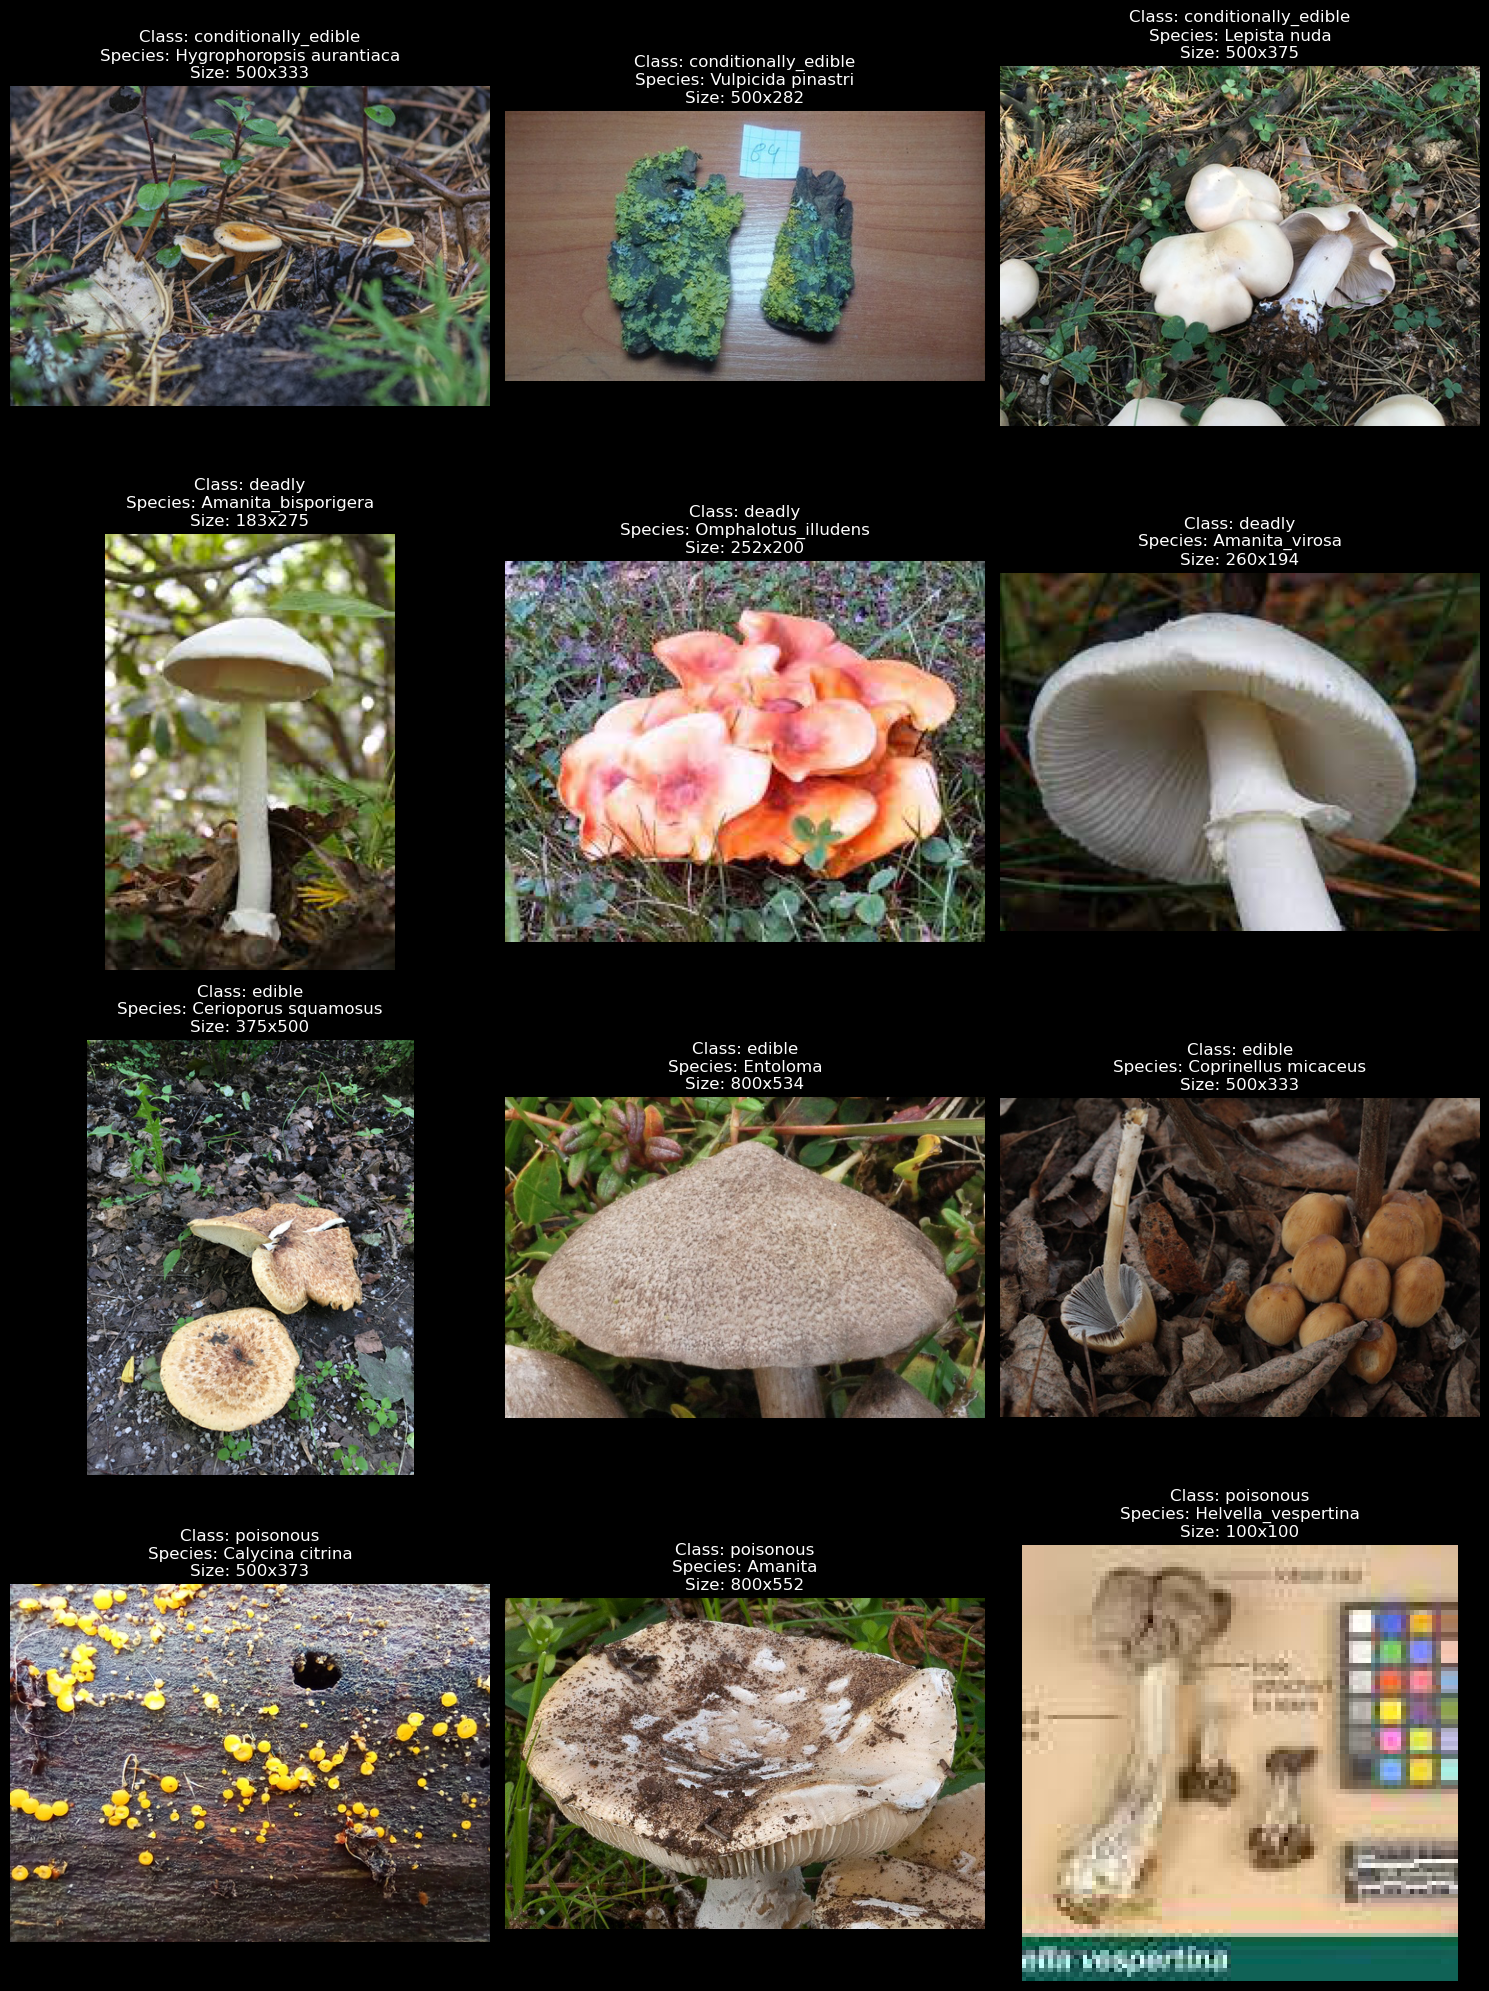

In [ ]:
# sample per class
sample_images = data.groupby("class", group_keys=False).sample(3, random_state=42)
cols = 3
rows = (len(sample_images) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
for ax, (_, row) in zip(axes.flatten(), sample_images.iterrows()):
    img = Image.open(row['file_path'])
    ax.imshow(img)
    ax.set_title(f"Class: {row['class']}\nSpecies: {row['species']}\nSize: {row['width']}x{row['height']}")
    ax.axis('off')
plt.tight_layout()
plt.show()